# Import các thư viện cần thiết

In [1]:
from vnstock import *
import pandas as pd
import numpy as np
from sklearn.svm import SVR
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.models import load_model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input, BatchNormalization
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import joblib

Phiên bản Vnstock 3.2.1 đã có mặt, vui lòng cập nhật với câu lệnh : `pip install vnstock --upgrade`.
Lịch sử phiên bản: https://vnstocks.com/docs/tai-lieu/lich-su-phien-ban
Phiên bản hiện tại 3.1.0.2

In [2]:
# Truy cập dữ liệu từ Vnstock
stock = Vnstock().stock(source='VCI') # Biến stock giúp truy xuất dữ liệu với source là VCI 
Vn100_list = stock.listing.symbols_by_group('VN100') # Lấy danh sách mã chứng khoán thuộc VN100
Vn100_list

2025-03-24 09:29:59 - vnstock.common.vnstock - INFO - Mã chứng khoán không được chỉ định, chương trình mặc định sử dụng VN30F1M
2025-03-24 09:29:59 - vnstock.common.data.data_explorer - INFO - Mã chứng khoán không được chỉ định, chương trình mặc định sử dụng VN30F1M
2025-03-24 09:29:59 - vnstock.common.data.data_explorer - WARNING - Thông tin niêm yết & giao dịch sẽ được truy xuất từ TCBS


0     AAA
1     ACB
2     ANV
3     BCG
4     BCM
     ... 
95    VNM
96    VPB
97    VPI
98    VRE
99    VTP
Name: symbol, Length: 100, dtype: object

# Chuẩn bị dữ liệu và lưu dưới dạng CSV

In [3]:
def get_data(start, end): # Nhập vào ngày bắt đầu và ngày kết thúc
    data = [] # Khởi tạo list data
    for sym in Vn100_list:
        try:
            temp = stock.quote.history(
                symbol = sym,
                start = start,
                end = end,
                interval = '1D'
            )
            temp = pd.DataFrame(temp) # Chuyển dữ liệu thành DataFrame
            temp['stock_id'] = sym # Thêm cột stock_id vào DataFrame, giá trị của cột này là mã chứng khoán
            data.append(temp) # Thêm DataFrame vào list data
        except Exception as e:
            print(f"Không thể lấy dữ liệu cho mã {sym}: {e}")
    # Tương tự với dữ liệu VNINDEX

    vnindex = pd.DataFrame(stock.quote.history(
            symbol = 'VNINDEX',
            start = start,
            end = end,
            interval = '1D'
        )
    )
    vnindex['stock_id'] = 'VNINDEX'
    data.append(vnindex)
    data = pd.concat(data, ignore_index= False) # Gộp các DataFrame trong list data thành một DataFrame duy nhất

    return data

In [4]:
stock_data = get_data('2024-09-01', '2025-03-15') # Lấy dữ liệu từ ngày 1/9/2024 đến 15/3/2025
stock_data.to_csv('stock_data.csv', index= False) # Lưu dữ liệu vào file csv

# Load file csv đã lưu từ trước

In [4]:
# Chuẩn bị dữ liệu test
# Dữ liệu này được lấy từ giai đoạn 01-09-2024 đến 15-03-2025 với hơn 100 ngày để test
# Dữ liệu dùng để huấn luyện là giai đoạn 01-01-2014 đến 21-02-2025, so với dữ liệu huấn luyện thì dữ liệu test sẽ có ngày cuối cùng không có trong tập dữ liệu
# đó sẽ là ngày được các mô hình dự đoán
def read_data(file_path, vn100_list):
    stock_df = pd.read_csv(file_path) # Đọc dữ liệu từ file csv
    stock_df['time'] = pd.to_datetime(stock_df['time']) # Chuyển cột date thành kiểu dữ liệu datetime

    temp = stock_df.groupby('stock_id')
    date_list = temp.get_group(vn100_list[0])['time'].tolist() # Lấy danh sách ngày từ dữ liệu của một mã chứng khoán bất kỳ

    stock_dict = {}
    for stock, stock_data in temp: # Gom nhóm dữ liệu theo mã chứng khoán, stock là tên các group, stock_data là dữ liệu của group đó
        # Kiểm tra xem dữ liệu của các mã chứng khoán có đồng nhất về số lượng ngày không
        if stock_data.shape[0] == len(date_list):
            stock_dict[stock] = stock_data.drop(columns= ['stock_id', 'time'])
        else:
            print(f"Dữ liệu của mã {stock} không đồng nhất với các mã chứng khoán khác")
            return None, None    

    return stock_dict, date_list

In [5]:
stocks_dict, date_list = read_data('stock_data.csv', Vn100_list) # Đọc dữ liệu từ file csv

In [6]:
print(stocks_dict.keys())
print(f"Ngày bắt đầu: {date_list[0]}")
print(f"Ngày kết thúc: {date_list[-1]}")
print(f"Số lượng ngày: {len(date_list)}")

dict_keys(['AAA', 'ACB', 'ANV', 'BCG', 'BCM', 'BID', 'BMP', 'BSI', 'BVH', 'BWE', 'CII', 'CMG', 'CTD', 'CTG', 'CTR', 'CTS', 'DBC', 'DCM', 'DGC', 'DGW', 'DIG', 'DPM', 'DSE', 'DXG', 'DXS', 'EIB', 'EVF', 'FPT', 'FRT', 'FTS', 'GAS', 'GEX', 'GMD', 'GVR', 'HAG', 'HCM', 'HDB', 'HDC', 'HDG', 'HHV', 'HPG', 'HSG', 'HT1', 'IMP', 'KBC', 'KDC', 'KDH', 'KOS', 'LPB', 'MBB', 'MSB', 'MSN', 'MWG', 'NAB', 'NKG', 'NLG', 'NT2', 'OCB', 'PAN', 'PC1', 'PDR', 'PHR', 'PLX', 'PNJ', 'POW', 'PPC', 'PTB', 'PVD', 'PVT', 'REE', 'SAB', 'SBT', 'SCS', 'SHB', 'SIP', 'SJS', 'SSB', 'SSI', 'STB', 'SZC', 'TCB', 'TCH', 'TLG', 'TPB', 'VCB', 'VCG', 'VCI', 'VGC', 'VHC', 'VHM', 'VIB', 'VIC', 'VIX', 'VJC', 'VND', 'VNINDEX', 'VNM', 'VPB', 'VPI', 'VRE', 'VTP'])
Ngày bắt đầu: 2024-09-04 00:00:00
Ngày kết thúc: 2025-03-14 00:00:00
Số lượng ngày: 132


# Xử lý quá trình dự đoán

In [18]:
def take_x_dates(stock_id, x_dates): # Hàm này giúp lấy dữ liệu của mã chứng khoán stock_id trong x_dates ngày cuối trong khoảng thời gian test
    return stocks_dict[stock_id][-x_dates-1:-1]

def predict_x_dates(model, input): # Hàm này giúp dự đoán giá cổ phiếu của mã chứng khoán trong x_dates ngày cuối trong khoảng thời gian test
    scaler = MinMaxScaler() # Min max scaler để chuẩn hóa dữ liệu
    temp = scaler.fit_transform(input)
    if type(model) == Sequential: # Nếu model là một mô hình của keras
        prediction = model.predict(np.expand_dims(temp, axis=0))
        prediction_reshaped = np.zeros((prediction.shape[0], 5)) # Tạo một mảng 2 chiều với 5 cột
        prediction_reshaped[:, 3] = prediction[:, 0].flatten() # Cột thứ 4 của mảng này sẽ chứa giá cổ phiếu dự đoán
        prediction = scaler.inverse_transform(prediction_reshaped)[:, 3] # Chuyển giá cổ phiếu dự đoán về dạng ban đầu (trước khi chuẩn hóa) để được giá trị thực
    else:
        prediction = model.predict(temp.flatten().reshape(1, -1))
        prediction_reshaped = np.zeros((prediction.shape[0], 5)) # Tạo một mảng 2 chiều với 5 cột
        prediction_reshaped[:, 3] = prediction # Cột thứ 4 của mảng này sẽ chứa giá cổ phiếu dự đoán
        prediction = scaler.inverse_transform(prediction_reshaped)[:, 3]

    return prediction

def predict_x_dates_all_stocks(model, x_dates): # Hàm này giúp dự đoán giá cổ phiếu của tất cả các mã chứng khoán trong x_dates ngày cuối trong khoảng thời gian test
    return np.array([predict_x_dates(model, take_x_dates(stock_id, x_dates)) for stock_id in Vn100_list]).reshape(1, -1)

def predict_with_all_models(models, x_dates=[10, 20, 30, 40, 50, 60, 70, 80, 90, 100], type = 0): # Hàm này giúp dự đoán giá cổ phiếu của tất cả các mã chứng khoán trong x_dates ngày cuối trong khoảng thời gian test với tất cả các mô hình
    n = len(models)
    predictions = np.empty((0, 100))
    if type == 1: # Nếu type = 1 thì dự đoán dựa trên 1 x_dates với cả 10 mô hình
        x_dates = [x_dates]
        for i in range(n):
            predictions = np.concatenate((predictions, predict_x_dates_all_stocks(models[i], x_dates[0])), axis=0)
    else: # Nếu type = 0 thì dự đoán dựa trên 10 x_dates riêng cho từng mô hình
        for i in range(n):
            if i <= 9:
                predictions = np.concatenate((predictions, predict_x_dates_all_stocks(models[i], x_dates[i])), axis=0)
            else: 
                predictions = np.concatenate((predictions, predict_x_dates_all_stocks(models[i], 30)), axis=0)

    return predictions

def compare_with_real_data(predictions, length = len(Vn100_list), show_comparation = 1): # Hàm này giúp so sánh giá cổ phiếu dự đoán với giá cổ phiếu thực tế trong x_dates ngày cuối trong khoảng thời gian test
    mae = 0
    actual = np.array([stocks_dict[stock].iloc[-1][3] for stock in Vn100_list]) # Lấy giá cổ phiếu thực tế của các mã chứng khoán

    for i in range (length): # Chạy danh sách các mã Vn100
        if show_comparation == 1:
            print(f"Mã: {Vn100_list[i]}, Giá thực tế: {actual[i]}") # In ra giá cổ phiếu dự đoán và giá cổ phiếu thực tế
            print(f"Giá dự đoán: {predictions[:, i]}")

    err_matrix = np.abs(predictions - actual) # Tính sai số tuyệt đối
    mae = np.sum(err_matrix, axis = 1)/length # Tính tổng sai số tuyệt đối 
    print(f"MAE: {mae}") # In ra giá trị trung bình của sai số tuyệt đối


    return mae

def comparation_plot(predictions, svr_prediction, lr_prediction, num_preds = 1, mae_sort = [], alpha=1.0): # Hàm này giúp vẽ biểu đồ so sánh giá cổ phiếu dự đoán với giá cổ phiếu thực tế trong x_dates ngày cuối trong khoảng thời gian test
    real_prices = [stocks_dict[stock].iloc[-1][3] for stock in Vn100_list]
    color_list = ['black', 'brown', 'pink', 'k', 'w', 'magenta', 'gray', 'yellow', 'silver', 'charcoal']
    styles = ['--', '-.', ':', '-', '--', '-.', ':', '-', '--', '-.']
    
    plt.figure(figsize=(25, 10))
    plt.plot(Vn100_list, real_prices, linestyle='-', color='red', label='Thực tế', linewidth=1.5)

    plt.plot(Vn100_list, svr_prediction, linestyle='-', color='blue', label='SVR', linewidth=1.5, alpha=alpha)
    plt.plot(Vn100_list, lr_prediction, linestyle='-', color='green', label='LR', linewidth=1.5, alpha=alpha)

    for i in range(num_preds):
        plt.plot(Vn100_list, predictions[mae_sort[i],:], linestyle=styles[i], color=color_list[i], label=f'LSTM_{i+1}', linewidth=1.5, alpha=alpha)
    
    plt.ylabel('Stocks Price')
    plt.xlabel('Stocks')
    plt.xticks(rotation=90)
    plt.legend()
    
    plt.show()

# Xử lý quá trình chọn và tối ưu hóa danh mục đầu tư


In [8]:
# Phần xây dựng danh mục đầu tư
def calculate_expected_return(predictions, previous = np.array([stocks_dict[i].iloc[-2][3] for i in Vn100_list])): # Hàm giúp tính lợi nhuận kỳ vọng
    return (predictions - previous) / previous 

def select_top_stocks(returns, num_stocks= 4): # Hàm giúp chọn ra 4 mã cổ phiếu có lợi nhuận kỳ vọng cao nhất
    top_indices = np.empty((0, num_stocks))
    for i in range(returns.shape[0]):
        temp = np.argsort(returns[i])[-num_stocks:]
        top_indices = np.concatenate((top_indices, temp.reshape(1, -1)), axis = 0) # Sắp xếp theo thứ tự tăng dần và chọn ra 4 mã cuối cùng
    return top_indices

def top_stocks_return(top_indices, returns): # Hàm giúp tính lợi nhuận kỳ vọng của 4 mã cổ phiếu được chọn
    top_returns = np.empty((0, 4))
    for i in range(12):
        temp = returns[i, top_indices[i].astype(int)]
        top_returns = np.concatenate((top_returns, temp.reshape(1, -1)), axis = 0)
    return top_returns

def covariance_matrix(ids, num_data): # Tính ma trận hiệp phương sai với số lượng dữ liệu là num_data
    closing_prices = []

    for id in ids:
        price_data = [day_data[3] for day_data in stocks_dict[id][-(num_data+2):-1].values] # Lấy giá cổ phiếu cuối cùng của mỗi ngày
        closing_prices.append(price_data)
    
    closing_prices = np.array(closing_prices).T
    daily_returns = (closing_prices[1:] - closing_prices[:-1]) / closing_prices[:-1] # Lấy close của ngày 2 - cuối, trừ cho close của 1 đến kế cuối 
    df_returns = pd.DataFrame(daily_returns, columns=ids)
    cov_matrix = df_returns.cov()
    return cov_matrix

def compute_needs(predictions, show = 0):
    predicted_returns = calculate_expected_return(predictions)
    top_indices = select_top_stocks(predicted_returns)
    top_ids = []
    for i in range(12):
        top_ids.append([Vn100_list[j] for j in top_indices[i].astype(int)])
    top_returns = top_stocks_return(top_indices, predicted_returns)
    if show == 1:
        print("Danh sách 4 cổ phiếu có lợi nhuận kỳ vọng cao nhất do các mô hình dự đoán.")
        for i in range(len(top_ids)):
            print(f"Model {i+1}: {top_ids[i]} -- Lợi nhuận: {top_returns[i]}")

    return top_returns, top_ids

# Mô phỏng Monte Carlo

def monte_carlo_simulation(num_simulations, top_returns, ids, num_day= 60): # Hàm mô phỏng Monte Carlo
    portfolios = []
    conv_maxtrix = covariance_matrix(ids, num_day) # Tính ma trận hiệp phương sai với 1000 dữ liệu

    for _ in range(num_simulations):
        random_weights = np.random.dirichlet(np.ones(4)) # Tạo ra 4 trọng số ngẫu nhiên
        por_return = np.dot(top_returns, random_weights) # Tính lợi nhuận của danh mục đầu tư
        por_volatility = np.sqrt(np.dot(random_weights.T, np.dot(conv_maxtrix, random_weights))) # Tính độ biến động của danh mục đầu tư
        portfolios.append((random_weights, por_return, por_volatility)) # Thêm danh mục đầu tư vào danh sách

    portfolios = sorted(portfolios, key=lambda x: x[1] / x[2], reverse=True) # Sắp xếp danh sách theo lợi nhuận giảm dần
    best_weights, best_return, best_volatility = portfolios[0] # Chọn ra danh mục đầu tư có lợi nhuận cao nhất

    print(f"Trọng số: {best_weights}, Lợi nhuận: {best_return}, Độ biến động: {best_volatility}") # In ra trọng số, lợi nhuận và độ biến động của danh mục đầu tư tốt nhất
    return portfolios, conv_maxtrix

# Mục tiêu là maximize sharpe ratio --> minimize negative sharpe ratio
def negative_sharpe(weights, top_returns, ids, risk_free_rate=0): # Hàm mục tiêu
    port_returns = np.dot(top_returns, weights)
    cov_matrix = covariance_matrix(ids, 60)
    port_volatility = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    sharpe_ratio = (port_returns - risk_free_rate) / port_volatility
    return -sharpe_ratio

def mean_variance_simulation(top_returns, ids, risk_rate=0, num_day= 60): # Hàm mô phỏng mean-variance
    history = []
    conv_maxtrixes = []

    def callback(weights):
        port_returns = np.dot(top_returns, weights)
        cov_matrix = covariance_matrix(ids, num_day)
        port_volatility = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
        history.append((weights.copy(), port_returns, port_volatility))
        conv_maxtrixes.append(cov_matrix)
        
    constraints = {'type': 'eq', 'fun': lambda x: np.sum(x) - 1} # Ràng buộc tổng trọng số bằng 1
    bounds = [(0, 1) for _ in range(4)] # Trọng số từ 0 đến 1
    initial_guess = [0.25, 0.25, 0.25, 0.25] # Trọng số ban đầu
    mean_variance_optimized = minimize(negative_sharpe, initial_guess, args=(top_returns, ids, risk_rate), bounds=bounds, constraints=constraints, callback=callback) # Tối ưu hóa trọng số

    best_weights = mean_variance_optimized.x
    best_return = np.dot(top_returns, best_weights)
    best_volatility = np.sqrt(np.dot(best_weights.T, np.dot(covariance_matrix(ids, num_day), best_weights)))

    history = sorted(history, key=lambda x: x[1] / x[2], reverse=True) # Sắp xếp danh sách theo lợi nhuận giảm dần

    print(f"Trọng số: {best_weights}, Lợi nhuận: {best_return}, Độ biến động: {best_volatility}") # In ra trọng số, lợi nhuận và độ biến động của danh mục đầu tư tốt nhất
    return history, conv_maxtrixes

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`


In [9]:
# Load model đã được huấn luyện
# Danh sách model
# 1. model_1_1 --- 6. model_6_2
# 2. model_2_3 --- 7. model_7_2
# 3. model_3_3 --- 8. model_8_2
# 4. model_4_2 --- 9. model_9_3
# 5. model_5_1 --- 10. model_10_2
model_1 = load_model('MODELS/model_1_1.keras')
model_2 = load_model('MODELS/model_2_3.keras')
model_3 = load_model('MODELS/model_3_3.keras')
model_4 = load_model('MODELS/model_4_2.keras')
model_5 = load_model('MODELS/model_5_1.keras')
model_6 = load_model('MODELS/model_6_2.keras')
model_7 = load_model('MODELS/model_7_2.keras')
model_8 = load_model('MODELS/model_8_2.keras')
model_9 = load_model('MODELS/model_9_3.keras')
model_10 = load_model('MODELS/model_10_2.keras')
model_11 = joblib.load("MODELS/svr_model.pkl")
model_12 = joblib.load("MODELS/lr_model.pkl")

models = [model_1, model_2, model_3, model_4, model_5, model_6, model_7, model_8, model_9, model_10, model_11, model_12] # Danh sách các mô hình

model_1.summary() # In ra thông tin của model

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 10, 128)        │        68,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 10, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 10, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,625 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 360,539 (1.38 MB)

 Trainable params: 120,051 (468.95 KB)

 Non-trainable params: 384 (1.50 KB)

 Optimizer params: 240,104 (937.91 KB)

In [10]:
predictions = predict_with_all_models(models, type = 0)
predictions.shape

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 415ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━

(12, 100)

In [11]:
mae_arr = compare_with_real_data(predictions, show_comparation=0) # So sánh giá cổ phiếu dự đoán với giá cổ phiếu thực tế

MAE: [1.3189318  1.2956713  1.31121576 1.28459973 1.32200324 1.39126214
 1.25441289 1.27522725 1.44778219 1.22967154 2.43584244 1.64289532]


Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`


In [12]:
mae_arr

array([1.3189318 , 1.2956713 , 1.31121576, 1.28459973, 1.32200324,
       1.39126214, 1.25441289, 1.27522725, 1.44778219, 1.22967154,
       2.43584244, 1.64289532])

In [13]:
mae_sort = mae_arr[:10].argsort()
mae_sort

array([9, 6, 7, 3, 1, 2, 0, 4, 5, 8])

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`


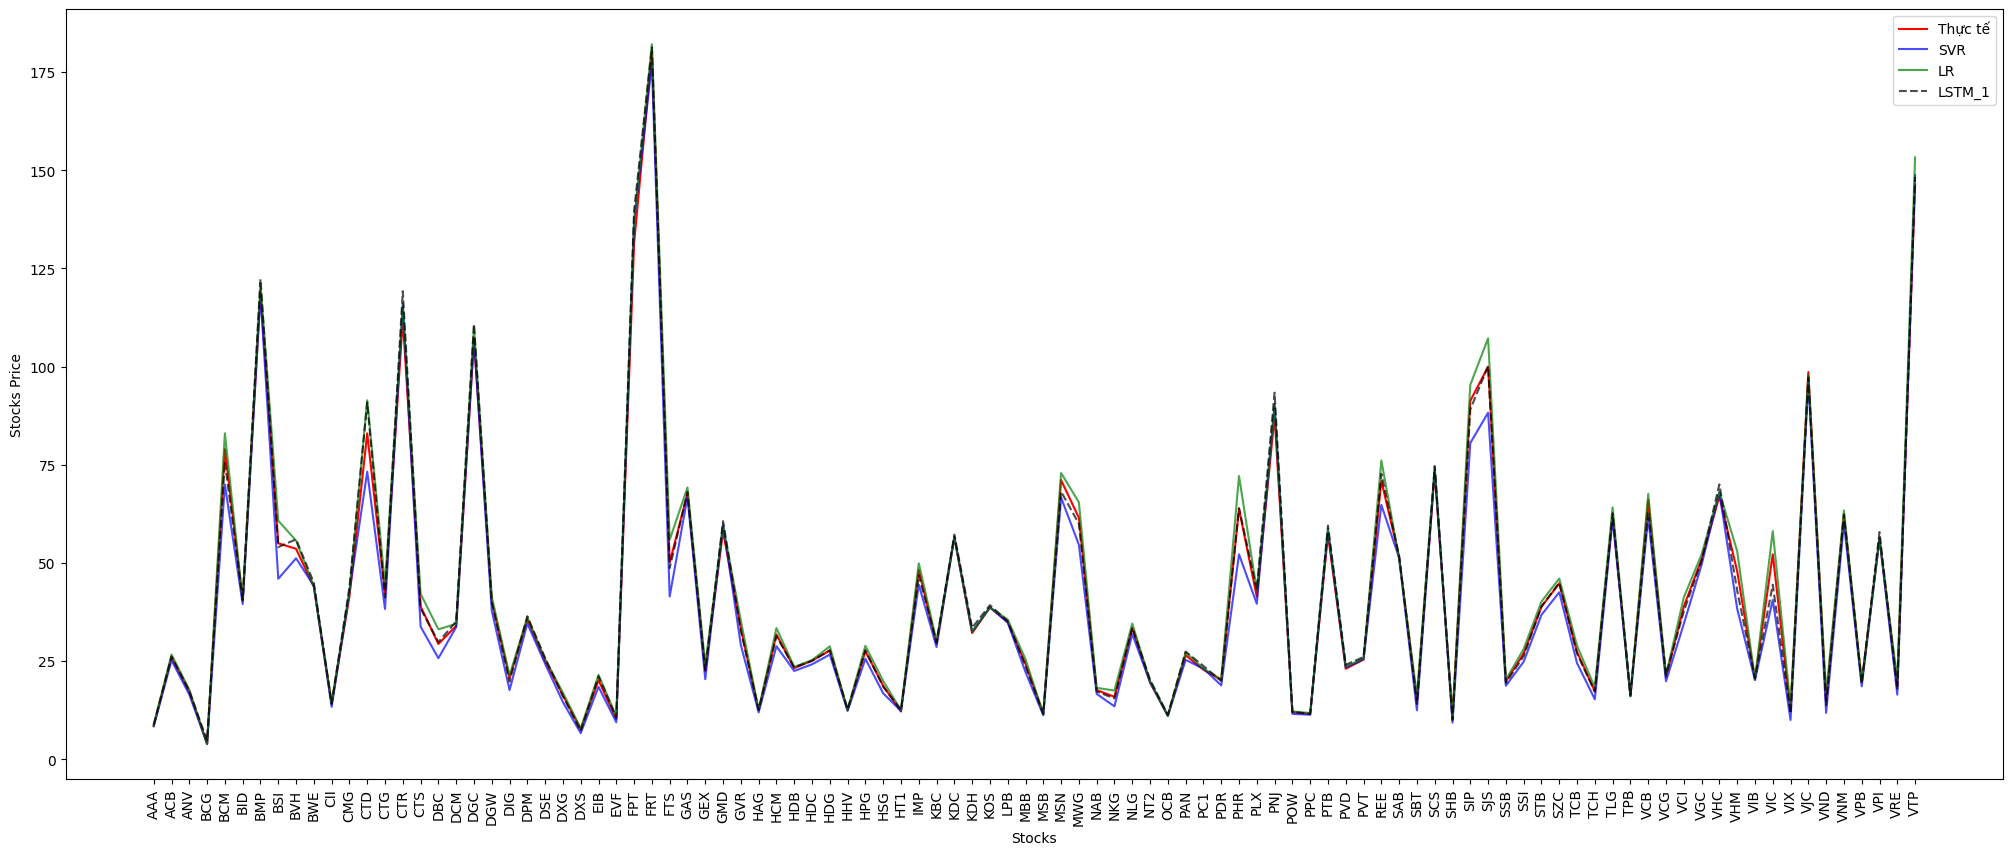

In [19]:
comparation_plot(predictions, predictions[-2], predictions[-1], num_preds=1, mae_sort=mae_sort, alpha= 0.7) # Vẽ biểu đồ so sánh giá cổ phiếu dự đoán với giá cổ phiếu thực tế

# Monte Carlos


In [13]:
top_returns, top_ids = compute_needs(predictions, show = 1)

Danh sách 4 cổ phiếu có lợi nhuận kỳ vọng cao nhất do các mô hình dự đoán.
Model 1: ['BVH', 'EIB', 'CTD', 'BCG'] -- Lợi nhuận: [0.04413883 0.05192593 0.06924917 0.20573277]
Model 2: ['BVH', 'EIB', 'CTD', 'BCG'] -- Lợi nhuận: [0.04902074 0.051723   0.07710713 0.23971263]
Model 3: ['PNJ', 'BVH', 'CTD', 'BCG'] -- Lợi nhuận: [0.03566687 0.03673164 0.05970944 0.24826077]
Model 4: ['EIB', 'BVH', 'CTD', 'BCG'] -- Lợi nhuận: [0.04387419 0.0477329  0.08025725 0.22456786]
Model 5: ['EIB', 'BVH', 'CTD', 'BCG'] -- Lợi nhuận: [0.04118149 0.04876084 0.08640395 0.2614395 ]
Model 6: ['BVH', 'EIB', 'CTD', 'BCG'] -- Lợi nhuận: [0.05612192 0.05672301 0.10629414 0.23666234]
Model 7: ['BVH', 'EIB', 'CTD', 'BCG'] -- Lợi nhuận: [0.04031021 0.04120298 0.0772068  0.23263917]
Model 8: ['BVH', 'EIB', 'CTD', 'BCG'] -- Lợi nhuận: [0.04187525 0.04293676 0.08019989 0.23357819]
Model 9: ['PNJ', 'BVH', 'CTD', 'BCG'] -- Lợi nhuận: [0.0436963  0.04595657 0.08060297 0.32012963]
Model 10: ['CTR', 'PNJ', 'CTD', 'BCG'] -- L

In [14]:
def mc_portfolio_plot(mc_portfolios):
    if mc_portfolios is not None:
        fig, axes = plt.subplots(2, 5, figsize=(20, 14))
        for i, ax in enumerate(axes.flat):
            mc_portfolio = mc_portfolios[i]
            mc_return = [p[1] for p in mc_portfolio]
            mc_volatility = [p[2] for p in mc_portfolio]

            
            sc = ax.scatter(mc_volatility, mc_return, c=np.array(mc_return) / np.array(mc_volatility), cmap='viridis')
            if i>=0 and i<=9:
                ax.set_title(f'Portfolio {i+1}')
            elif i == 10:
                ax.set_title('SVR Portfolio')
            else:
                ax.set_title('LR Portfolio')
            ax.grid(True)

        fig.supxlabel('Volatility')
        fig.supylabel('Return')
        fig.colorbar(sc, ax=axes, orientation="horizontal", fraction=0.02, pad=0.1, label='Sharpe Ratio')
        plt.subplots_adjust(bottom=0.2, left= 0.05) 
        plt.show()

def mv_portfolio_plot(mv_portfolios):
    if mv_portfolios is not None:
        fig, axes = plt.subplots(2, 5, figsize=(18, 10))
        for i, ax in enumerate(axes.flat):
            mv_portfolio = mv_portfolios[i]
            mv_return = [p[1] for p in mv_portfolio]
            mv_volatility = [p[2] for p in mv_portfolio]

            
            sc = ax.scatter(mv_volatility, mv_return, c=np.array(mv_return) / np.array(mv_volatility), cmap='viridis')
            if i>=0 and i<=9:
                ax.set_title(f'Portfolio {i+1}')
            elif i == 10:
                ax.set_title('SVR Portfolio')
            else:
                ax.set_title('LR Portfolio')
            ax.grid(True)

        fig.supxlabel('Volatility')
        fig.supylabel('Return')
        fig.colorbar(sc, ax=axes, orientation="horizontal", fraction=0.02, pad=0.1, label='Sharpe Ratio')
        plt.subplots_adjust(bottom=0.2, left= 0.05) 
        # plt.rcParams.update({
        #     "font.size": 10,  # Kích thước chữ mặc định
        #     "axes.titlesize": 10,  # Tiêu đề biểu đồ
        #     "axes.labelsize": 10,  # Nhãn trục x/y
        #     "xtick.labelsize": 7,  # Kích thước số trên trục x
        #     "ytick.labelsize": 5,  # Kích thước số trên trục y
        #     "legend.fontsize": 5  # Kích thước chữ trong legend
        # })
        plt.show()



In [1]:
num_simulations = 1000
mc_portfolios = []
mc_conv_matrixes = []

for i in range(10):
    portfolio, conv_max = monte_carlo_simulation(num_simulations, top_returns[i], top_ids[i], num_day= 60)
    mc_portfolios.append(portfolio)
    mc_conv_matrixes.append(conv_max)

mc_portfolio_plot(mc_portfolios)

NameError: name 'monte_carlo_simulation' is not defined

# Mean Variance

Trọng số: [0.39818391 0.19172654 0.10856612 0.30152344], Lợi nhuận: 0.018222339581091762, Độ biến động: 0.010224855242596087
Trọng số: [1.32272665e-17 5.52912521e-01 4.69534291e-02 4.00134050e-01], Lợi nhuận: 0.027818555672395048, Độ biến động: 0.011467016861147207
Trọng số: [0.04483387 0.5105892  0.01623673 0.4283402 ], Lợi nhuận: 0.025565087023824942, Độ biến động: 0.011421704355949712
Trọng số: [0.46824425 0.3035568  0.02137802 0.20682093], Lợi nhuận: 0.02347307065345627, Độ biến động: 0.007686586775461207
Trọng số: [1.01643953e-17 5.02955220e-01 4.57179400e-02 4.51326840e-01], Lợi nhuận: 0.03308780381304088, Độ biến động: 0.011646194535796104
Trọng số: [0.03047327 0.47812106 0.40648047 0.0849252 ], Lợi nhuận: 0.035243776288339364, Độ biến động: 0.011531039180448328
Trọng số: [5.89898063e-01 9.46103314e-17 2.03793467e-01 2.06308471e-01], Lợi nhuận: 0.023355154611522704, Độ biến động: 0.008380851280493495
Trọng số: [0.48515008 0.18697759 0.150995   0.17687732], Lợi nhuận: 0.022275466

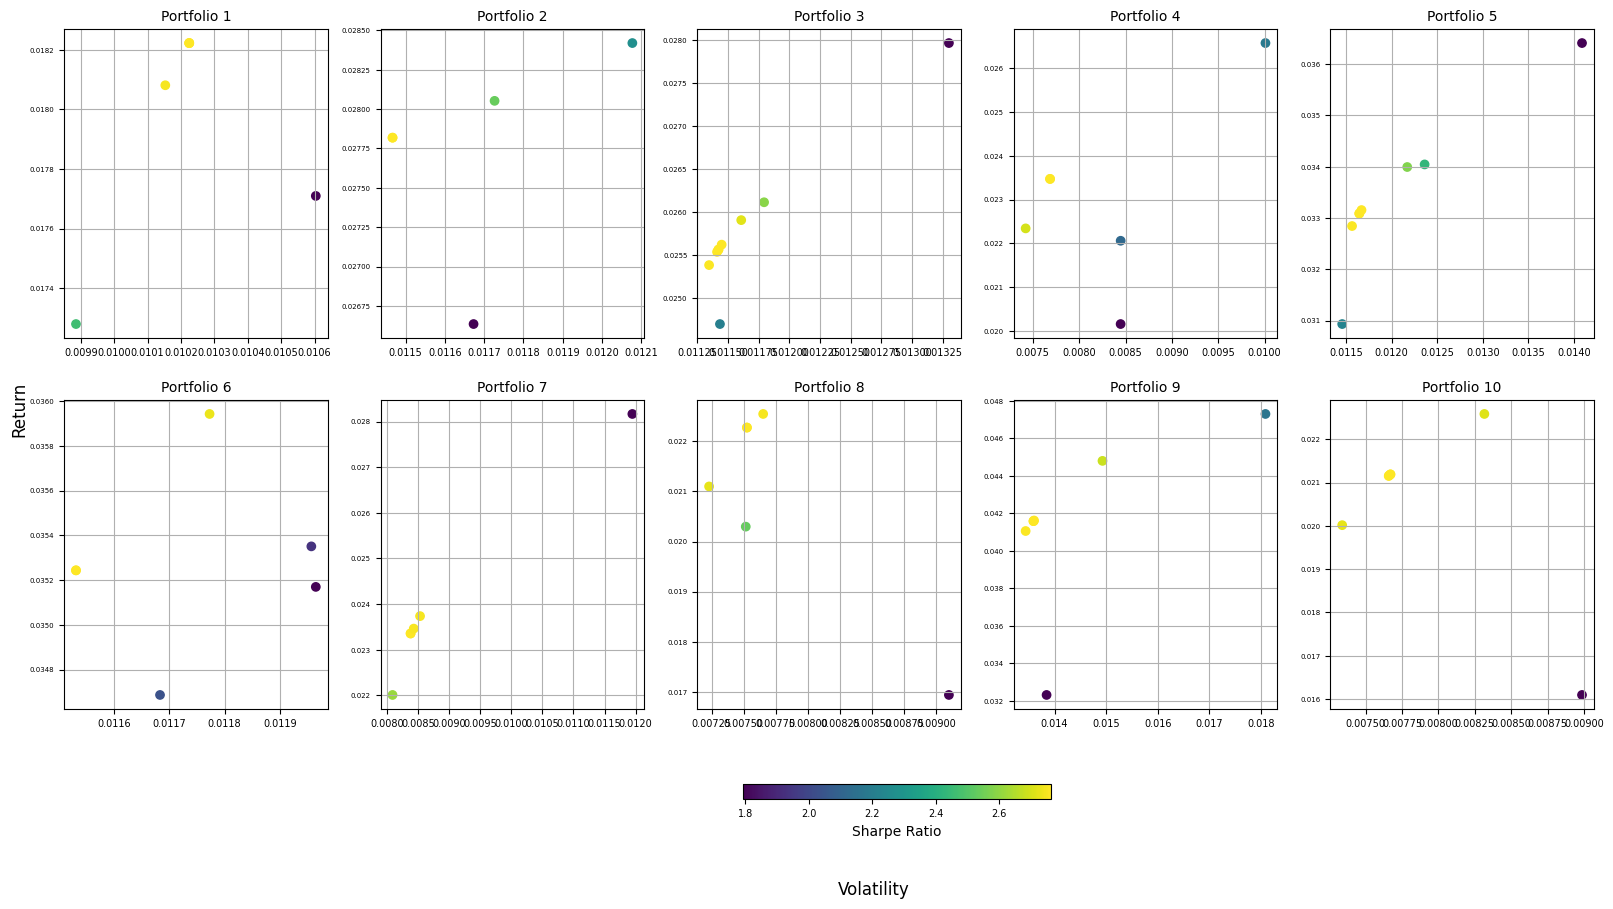

In [89]:
mv_portfolios = []
mv_conv_matrixes = []

for i in range(10):
    portfolio, conv_max = mean_variance_simulation(top_returns[i], top_ids[i], risk_rate=0) # Mô phỏng mean-variance
    mv_portfolios.append(portfolio)
    mv_conv_matrixes.append(conv_max)

mv_portfolio_plot(mv_portfolios)


In [40]:
# compare 2 kết quả sharpe ratio (mức độ hiệu quả) của portfolio
# Sharpe ratio cao hơn thì portfolio đó hiệu quả hơn
# > 1.0 là tốt, > 2.0 là rất tốt, > 3.0 là quá tốt
for i in range(10):
    print(f"Portfolio {i+1}")
    print("Monte Carlo")
    print(f"Return: {mc_portfolios[i][0][1]} -- Volatility: {mc_portfolios[i][0][2]}")
    print(f"Sharpe ratio: {mc_portfolios[i][0][1] / mc_portfolios[i][0][2]}")
    print("Mean Variance")
    print(f"Return: {mv_portfolios[i][0][1]} -- Volatility: {mv_portfolios[i][0][2]}")
    print(f"Mean Variance: {mv_portfolios[i][0][1] / mv_portfolios[i][0][2]}")
    print("")

Portfolio 1
Monte Carlo
Return: 0.018041451170532925 -- Volatility: 0.010131487524611422
Sharpe ratio: 1.7807307294912627
Mean Variance
Return: 0.018222339581091762 -- Volatility: 0.010224855242596087
Mean Variance: 1.782161130768744

Portfolio 2
Monte Carlo
Return: 0.027715008190787472 -- Volatility: 0.01142958103696476
Sharpe ratio: 2.424849003752063
Mean Variance
Return: 0.027818555672395048 -- Volatility: 0.011467016861147207
Mean Variance: 2.4259627424679624

Portfolio 3
Monte Carlo
Return: 0.025482175260876608 -- Volatility: 0.011390133213745181
Sharpe ratio: 2.237214858042721
Mean Variance
Return: 0.025565087023824942 -- Volatility: 0.011421704355949712
Mean Variance: 2.2382900333528384

Portfolio 4
Monte Carlo
Return: 0.02327652209354687 -- Volatility: 0.007627353616620981
Sharpe ratio: 3.05171665868806
Mean Variance
Return: 0.02347307065345627 -- Volatility: 0.007686586775461207
Mean Variance: 3.053770332547615

Portfolio 5
Monte Carlo
Return: 0.03308019905007732 -- Volatility

In [39]:
vn_index_return = (stocks_dict['VNINDEX'][-1][3] - stocks_dict['VNINDEX'][-2][3]) / stocks_dict['VNINDEX'][-2][3] # Lợi nhuận của VNINDEX
vn_index_return

np.float64(0.00291574502312486)

In [40]:
stocks_dict['VNINDEX'][-1]

array([1.29298000e+03, 1.29675000e+03, 1.29098000e+03, 1.29675000e+03,
       7.30210454e+08])

In [41]:
stocks_dict['VNINDEX'][-2]

array([1.288560e+03, 1.295820e+03, 1.288560e+03, 1.292980e+03,
       7.644144e+08])